# DAY 160 - Question & Answering (Q&A).
@A.IPYNB

# Building a Question Answering System (Extractive QA)

### The Concept
In Extractive QA, the model is given two inputs:
1.  **Context:** A paragraph of text (e.g., a Wikipedia article).
2.  **Question:** A query related to the text.

The model does **not** write an answer. Instead, it predicts two numbers:
* **Start Index:** The token where the answer begins.
* **End Index:** The token where the answer ends.



### The Model: DistilBERT-SQuAD
We will use a **DistilBERT** model that has been fine-tuned on **SQuAD** (Stanford Question Answering Dataset). It is small, fast, and highly accurate for finding facts in text.

In [15]:
# @title 1. Install & Load Model
!pip install -q transformers torch

from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch

# Here I am Loading a model fine-tuned on SQuAD (Stanford Question Answering Dataset)
model_name = "distilbert-base-cased-distilled-squad"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name)

print("Model loaded. Ready to answer questions.")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Model loaded. Ready to answer questions.


### How it Works: Logits & Spans
We won't just use a "magic function" yet. Let's see the raw math.

1.  **Tokenize:** Convert `Question + [SEP] + Context` into IDs.
2.  **Forward Pass:** The model outputs `start_logits` and `end_logits` for every token.
3.  **Argmax:** We find the token with the highest "Start Score" and the token with the highest "End Score".
4.  **Decode:** We convert those token IDs back into string text.

In [16]:
# @title 2. The "Under the Hood" Function
def manual_qa(question, context):
    inputs = tokenizer(question, context, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)

    answer_start_index = torch.argmax(outputs.start_logits)
    answer_end_index = torch.argmax(outputs.end_logits) + 1

    # This is to Decode the answer span
    # We grab the input_ids from the start to the end index
    answer_tokens = inputs.input_ids[0, answer_start_index : answer_end_index]
    answer = tokenizer.decode(answer_tokens)

    return answer

# TEST
context_text = """
The Amazon rainforest, alternatively, the Amazon Jungle or Amazonia, is a moist broadleaf
tropical rainforest in the Amazon biome that covers most of the Amazon basin of South America.
This basin encompasses 7,000,000 km2 (2,700,000 sq mi), of which 5,500,000 km2 (2,100,000 sq mi)
are covered by the rainforest. This region includes territory belonging to nine nations.
The majority of the forest is contained within Brazil, with 60% of the rainforest,
followed by Peru with 13%, Colombia with 10%, and with minor amounts in distinct countries.
"""

question_1 = "How much of the basin is covered by rainforest?"
question_2 = "Which country has the largest portion of the forest?"

print(f"Q: {question_1}")
print(f"A: {manual_qa(question_1, context_text)}\n")

print(f"Q: {question_2}")
print(f"A: {manual_qa(question_2, context_text)}")

Q: How much of the basin is covered by rainforest?
A: 5, 500, 000 km2 ( 2, 100, 000 sq mi )

Q: Which country has the largest portion of the forest?
A: Brazil


### The Easy Way: Hugging Face Pipelines
Now that you understand the math (logits -> argmax -> decode), we can use the production-ready wrapper.
The `pipeline` handles complex edge cases, like:
* Questions where the answer is longer than the max sequence length.
* Giving a "Confidence Score" for the answer.

In [17]:
# @title 3. Pipeline
from transformers import pipeline
qa_pipeline = pipeline("question-answering", model=model, tokenizer=tokenizer)

# Let's try a harder context
technical_context = """
Transformers are a type of deep learning model that utilizes the mechanism of self-attention,
differing from Recurrent Neural Networks (RNNs) that process data sequentially.
Introduced in the 2017 paper 'Attention Is All You Need', they have become the foundation
of models like BERT and GPT. The key innovation is the ability to process the entire input
sequence in parallel, significantly reducing training time.
"""

questions = [
    "What paper introduced Transformers?",
    "How do Transformers differ from RNNs?",
    "What is the key innovation?"
]

print("--- AI Answers ---")
for q in questions:
    result = qa_pipeline(question=q, context=technical_context)
    print(f"Q: {q}")
    print(f"A: {result['answer']}")
    print(f"Confidence: {result['score']:.4f}\n")

--- AI Answers ---
Q: What paper introduced Transformers?
A: Attention Is All You Need
Confidence: 0.6968

Q: How do Transformers differ from RNNs?
A: process data sequentially
Confidence: 0.6702

Q: What is the key innovation?
A: the ability to process the entire input
sequence in parallel, significantly reducing training time
Confidence: 0.2142



### Visualizing the Model's "Thought Process"
Let's plot the Start and End probabilities.
You will see a spike in the graph exactly where the answer is located in the text.

In [18]:
def print_qa_logits(question, context, top_k=10):
    device = next(model.parameters()).device
    inputs = tokenizer(question, context, return_tensors="pt")
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    start_probs = torch.softmax(outputs.start_logits, dim=-1).cpu().numpy()[0]
    end_probs = torch.softmax(outputs.end_logits, dim=-1).cpu().numpy()[0]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].cpu())

    print("TOP START POSITIONS:")
    start_indices = np.argsort(start_probs)[-top_k:][::-1]
    for idx in start_indices:
        print(f"Token: {tokens[idx]:15s} | Start Prob: {start_probs[idx]:.4f} | Index: {idx}")

    print("\nTOP END POSITIONS:")
    end_indices = np.argsort(end_probs)[-top_k:][::-1]
    for idx in end_indices:
        print(f"Token: {tokens[idx]:15s} | End Prob: {end_probs[idx]:.4f} | Index: {idx}")

    print("\nFIRST 20 TOKENS:")
    for i, token in enumerate(tokens[:20]):
        print(f"{i:3d}: {token:15s} | Start: {start_probs[i]:.4f} | End: {end_probs[i]:.4f}")

print_qa_logits("What is the key innovation?", technical_context)

TOP START POSITIONS:
Token: the             | Start Prob: 0.4693 | Index: 82
Token: ability         | Start Prob: 0.3836 | Index: 83
Token: to              | Start Prob: 0.0983 | Index: 84
Token: process         | Start Prob: 0.0352 | Index: 85
Token: The             | Start Prob: 0.0060 | Index: 78
Token: is              | Start Prob: 0.0018 | Index: 81
Token: entire          | Start Prob: 0.0014 | Index: 87
Token: input           | Start Prob: 0.0011 | Index: 88
Token: reducing        | Start Prob: 0.0011 | Index: 94
Token: the             | Start Prob: 0.0009 | Index: 86

TOP END POSITIONS:
Token: time            | End Prob: 0.4565 | Index: 96
Token: parallel        | End Prob: 0.3232 | Index: 91
Token: .               | End Prob: 0.1493 | Index: 97
Token: sequence        | End Prob: 0.0554 | Index: 89
Token: ,               | End Prob: 0.0139 | Index: 92
Token: input           | End Prob: 0.0004 | Index: 88
Token: process         | End Prob: 0.0003 | Index: 85
Token: reducing      

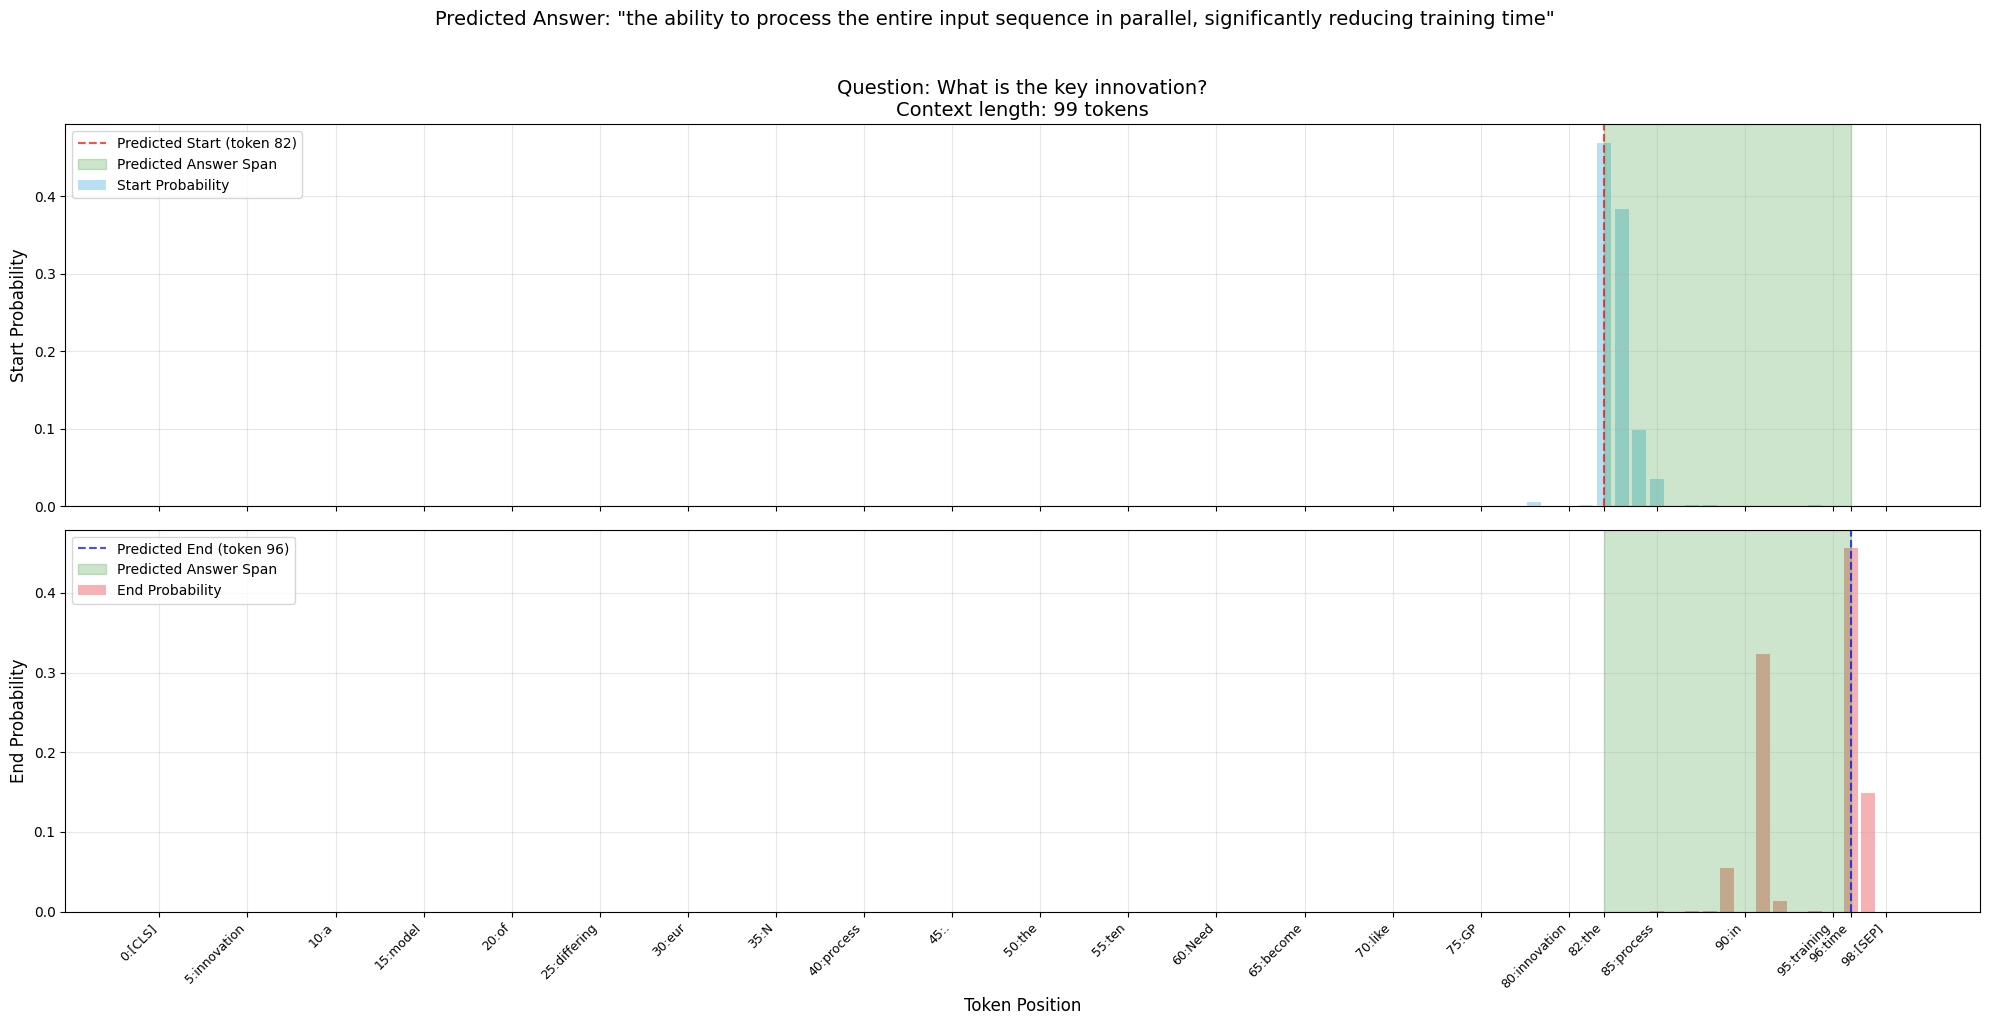

SUMMARY:
Question: What is the key innovation?
Predicted answer start: token 82 ('the')
Predicted answer end: token 96 ('time')
Answer span: tokens 82 to 96
Answer text: 'the ability to process the entire input sequence in parallel, significantly reducing training time'


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

def plot_qa_logits_enhanced(question, context):
    device = next(model.parameters()).device
    inputs = tokenizer(question, context, return_tensors="pt")
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    start_probs = torch.softmax(outputs.start_logits, dim=-1).cpu().numpy()[0]
    end_probs = torch.softmax(outputs.end_logits, dim=-1).cpu().numpy()[0]

    token_ids = inputs["input_ids"][0].cpu()
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    pred_start = np.argmax(start_probs)
    pred_end = np.argmax(end_probs)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

    display_tokens = []
    for i, token in enumerate(tokens):
        if token == '[CLS]':
            display_tokens.append('[CLS]')
        elif token == '[SEP]':
            display_tokens.append('[SEP]')
        elif token.startswith('##'):
            display_tokens.append(token[2:])
        else:
            display_tokens.append(token)

    x_indices = range(len(start_probs))
    ax1.bar(x_indices, start_probs, alpha=0.6, color='skyblue', label='Start Probability')
    ax1.axvline(x=pred_start, color='red', linestyle='--', alpha=0.7, label=f'Predicted Start (token {pred_start})')
    ax1.set_ylabel('Start Probability', fontsize=12)
    ax1.set_title(f'Question: {question}\nContext length: {len(tokens)} tokens', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.bar(x_indices, end_probs, alpha=0.6, color='lightcoral', label='End Probability')
    ax2.axvline(x=pred_end, color='blue', linestyle='--', alpha=0.7, label=f'Predicted End (token {pred_end})')
    ax2.set_ylabel('End Probability', fontsize=12)
    ax2.set_xlabel('Token Position', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    if pred_start <= pred_end:
        ax1.axvspan(pred_start, pred_end, alpha=0.2, color='green', label='Predicted Answer Span')
        ax2.axvspan(pred_start, pred_end, alpha=0.2, color='green', label='Predicted Answer Span')
        ax1.legend()
        ax2.legend()
        answer_tokens = tokens[pred_start:pred_end+1]
        answer_text = tokenizer.convert_tokens_to_string(answer_tokens)
        fig.suptitle(f'Predicted Answer: "{answer_text}"', fontsize=14, y=1.02)

    tick_positions = list(range(0, len(tokens), 5))
    tick_labels = [f"{pos}:{display_tokens[pos]}" for pos in tick_positions]
    ax2.set_xticks(tick_positions)
    ax2.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=9)

    important_positions = [0, pred_start, pred_end, len(tokens)-1]
    for pos in important_positions:
        if pos not in tick_positions:
            tick_positions.append(pos)
            tick_labels.append(f"{pos}:{display_tokens[pos]}")

    tick_positions, tick_labels = zip(*sorted(zip(tick_positions, tick_labels)))
    ax2.set_xticks(tick_positions)
    ax2.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=9)

    plt.tight_layout()
    plt.show()

    print("=" * 80)
    print("SUMMARY:")
    print(f"Question: {question}")
    print(f"Predicted answer start: token {pred_start} ('{tokens[pred_start]}')")
    print(f"Predicted answer end: token {pred_end} ('{tokens[pred_end]}')")
    print(f"Answer span: tokens {pred_start} to {pred_end}")
    print(f"Answer text: '{answer_text}'")
    print("=" * 80)

plot_qa_logits_enhanced("What is the key innovation?", technical_context)

### The Strategic Win

We have built a system that can **read**.

1.  **Search Engines:** This is how Google highlights the answer in the search snippet.
2.  **Legal Tech:** "What is the termination clause in this contract?" (Context: 50-page PDF).
3.  **Customer Support:** "How do I reset my password?" (Context: Knowledge Base).

**Next Step:**
We can combine this with the **Semantic Search** project that we've built earlier.
1.  Use **SBERT** to find the right paragraph.
2.  Use **QA Model** to extract the exact answer from that paragraph.
**That is the full RAG architecture.**